# PCA & Clustering – Wine Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

file_path = r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 14\wine.csv"
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    df = pd.read_csv("/mnt/data/wine.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (178, 14)


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Task 1 – EDA

In [2]:
display(df.describe().T)
print("\nMissing values:")
display(df.isnull().sum())

,count,mean,std,min,25%,50%,75%,max
Type,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoids,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58



Missing values:


Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

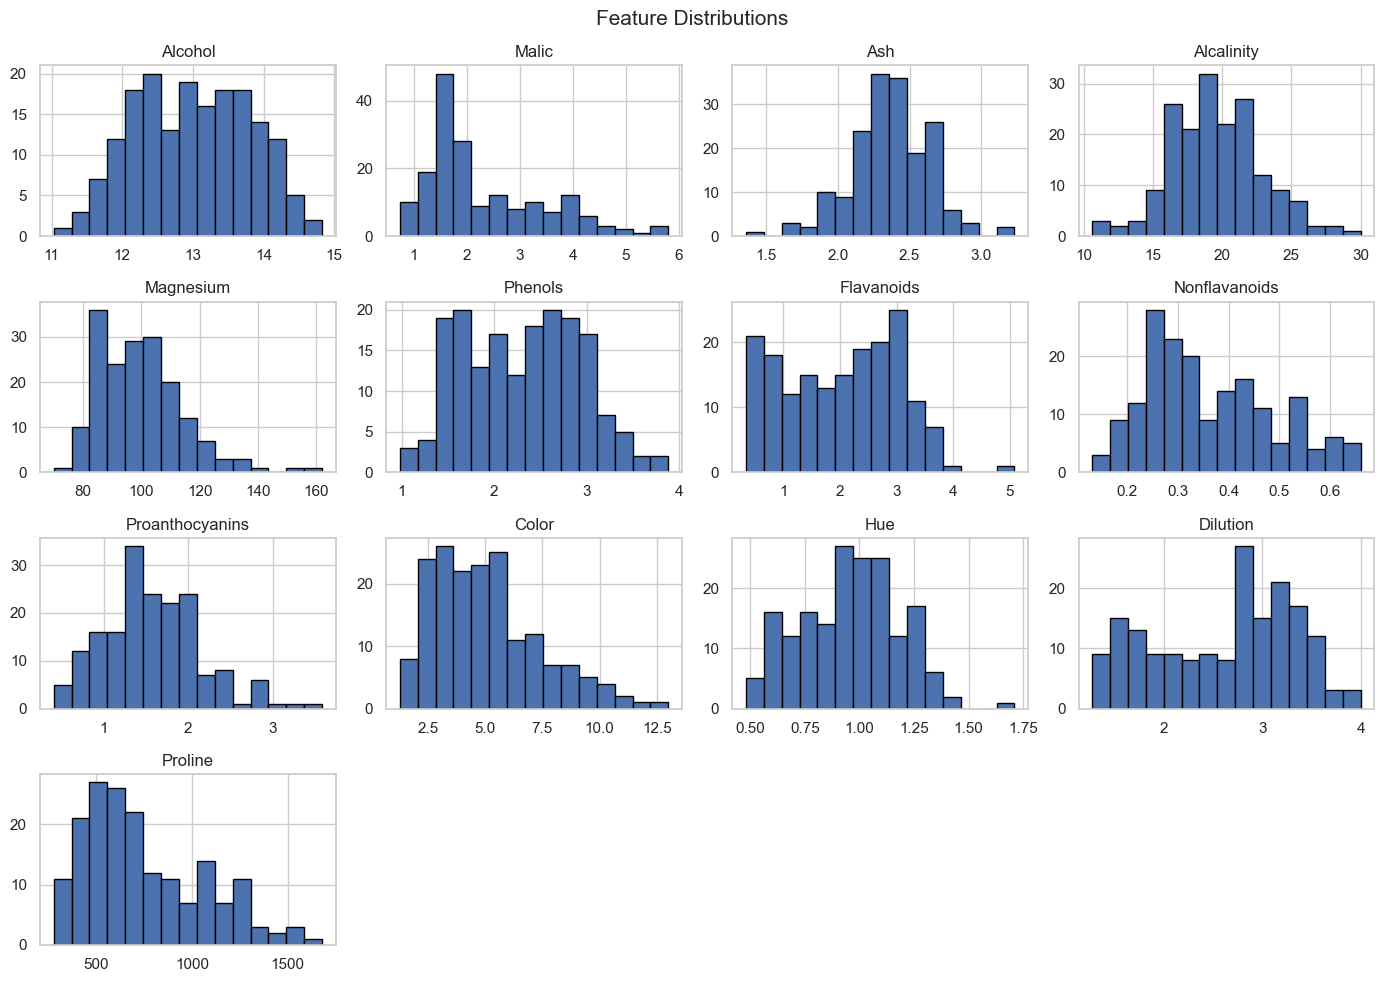

In [3]:
# Feature distributions
df.drop(columns=["Type"]).hist(figsize=(14, 10), bins=15, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=15)
plt.tight_layout()
plt.show()

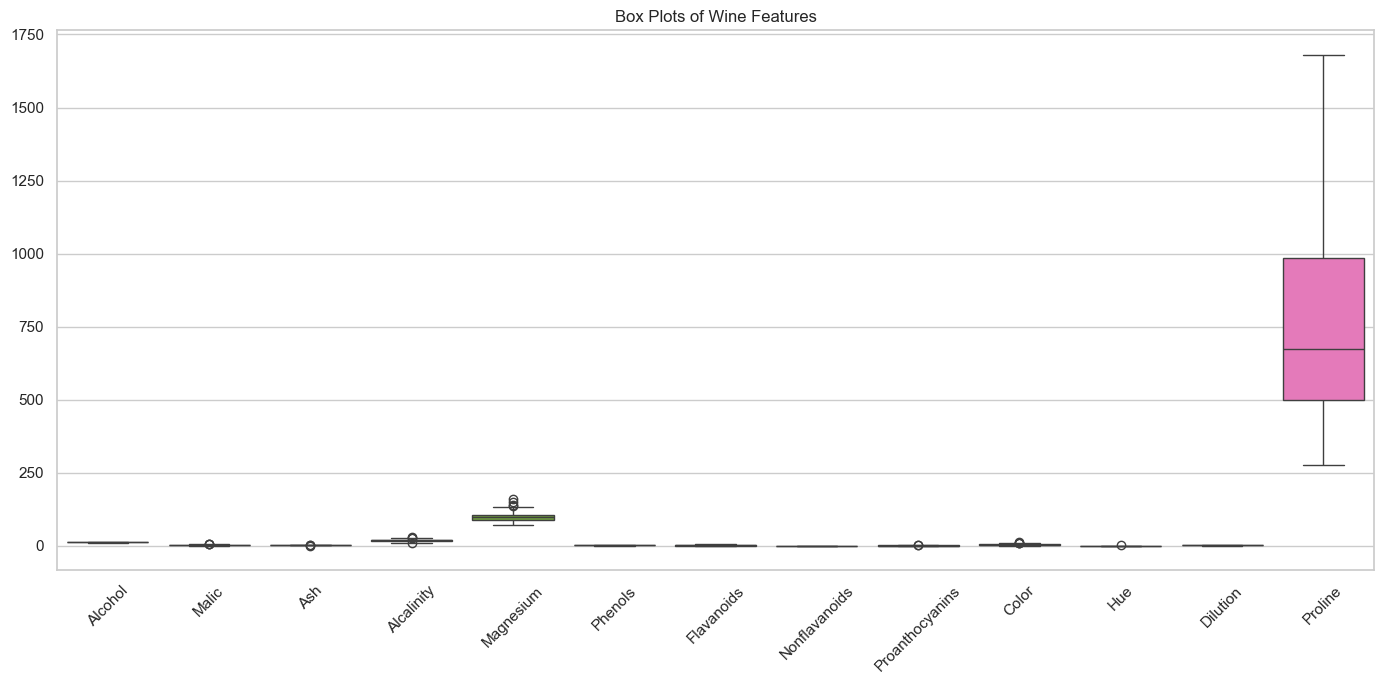

In [4]:
# Box plots
plt.figure(figsize=(14, 7))
sns.boxplot(data=df.drop(columns=["Type"]))
plt.title("Box Plots of Wine Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

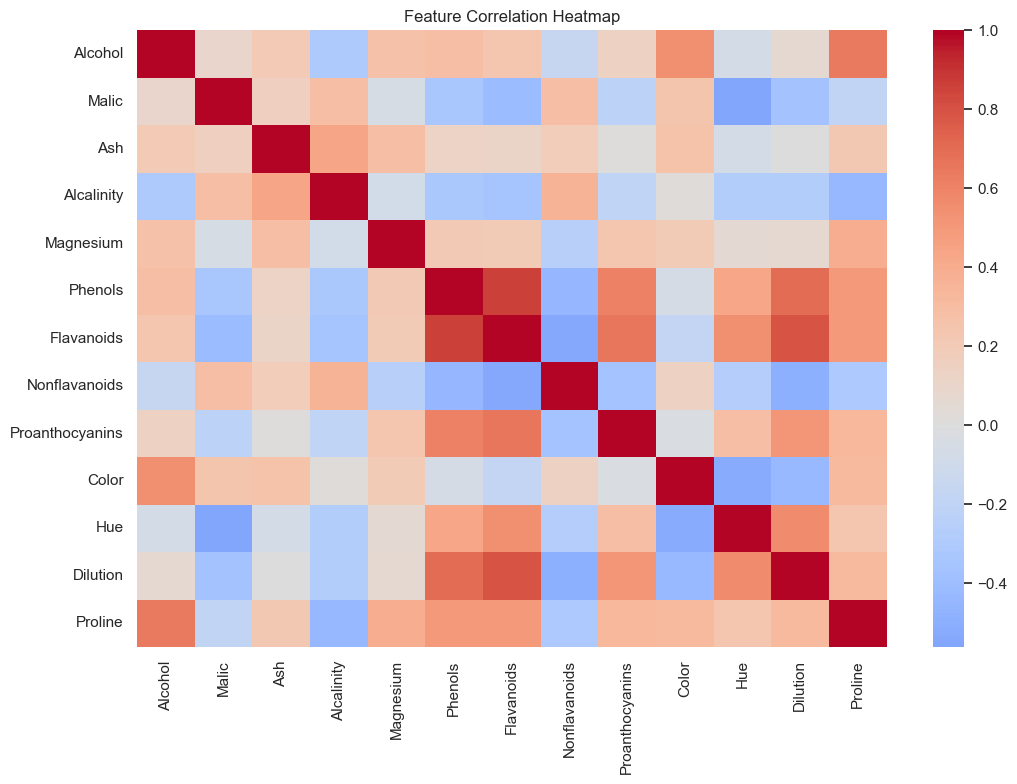

In [5]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(df.drop(columns=["Type"]).corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Task 2 – PCA

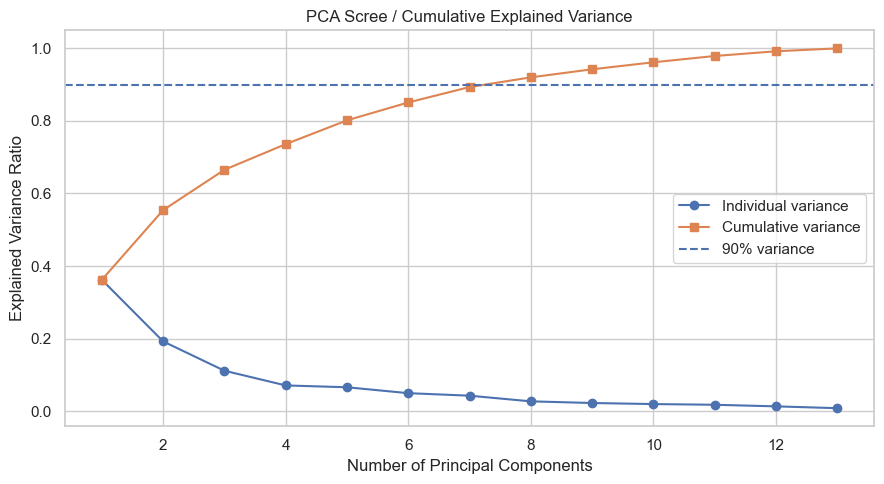

Components needed for >=90% variance: 8
PCA transformed shape: (178, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700


In [7]:
# Standardize the 13 numerical wine features
X = df.drop(columns=["Type"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with all components
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Scree + cumulative explained variance
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(explained)+1), explained, marker="o", label="Individual variance")
ax.plot(range(1, len(cumulative)+1), cumulative, marker="s", label="Cumulative variance")
ax.axhline(0.90, linestyle="--", label="90% variance")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Scree / Cumulative Explained Variance")
ax.legend()
plt.tight_layout()
plt.show()

# Minimum components explaining at least 90%
n_components = np.argmax(cumulative >= 0.90) + 1
print("Components needed for >=90% variance:", n_components)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i}" for i in range(1, n_components + 1)]
)
print("PCA transformed shape:", pca_df.shape)
display(pca_df.head())

## Task 3 & 4 – K-Means on Original and PCA Data

C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

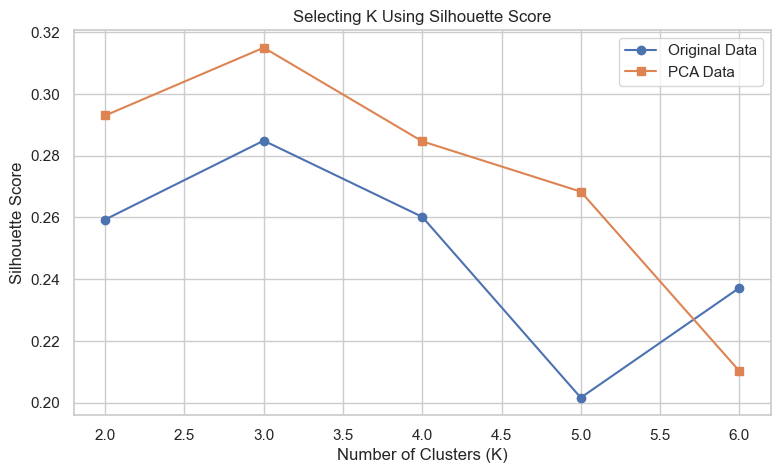

Best K - Original: 3
Best K - PCA: 3


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Data,K,Silhouette Score,Davies-Bouldin Index
0,Original,3,0.2849,1.3892
1,PCA,3,0.3150,1.2669


In [8]:
# Find a suitable K using silhouette score on the standardized original data
k_values = range(2, 7)
orig_sil = []
pca_sil = []

for k in k_values:
    km_o = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_o = km_o.fit_predict(X_scaled)
    orig_sil.append(silhouette_score(X_scaled, labels_o))

    km_p = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_p = km_p.fit_predict(X_pca)
    pca_sil.append(silhouette_score(X_pca, labels_p))

plt.figure(figsize=(9, 5))
plt.plot(k_values, orig_sil, marker="o", label="Original Data")
plt.plot(k_values, pca_sil, marker="s", label="PCA Data")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Selecting K Using Silhouette Score")
plt.legend()
plt.show()

best_k_original = list(k_values)[np.argmax(orig_sil)]
best_k_pca = list(k_values)[np.argmax(pca_sil)]

print("Best K - Original:", best_k_original)
print("Best K - PCA:", best_k_pca)

# Use the best K for each representation
kmeans_original = KMeans(n_clusters=best_k_original, random_state=42, n_init=10)
labels_original = kmeans_original.fit_predict(X_scaled)

kmeans_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

# Metrics
results = pd.DataFrame({
    "Data": ["Original", "PCA"],
    "K": [best_k_original, best_k_pca],
    "Silhouette Score": [
        silhouette_score(X_scaled, labels_original),
        silhouette_score(X_pca, labels_pca)
    ],
    "Davies-Bouldin Index": [
        davies_bouldin_score(X_scaled, labels_original),
        davies_bouldin_score(X_pca, labels_pca)
    ]
})

display(results.round(4))

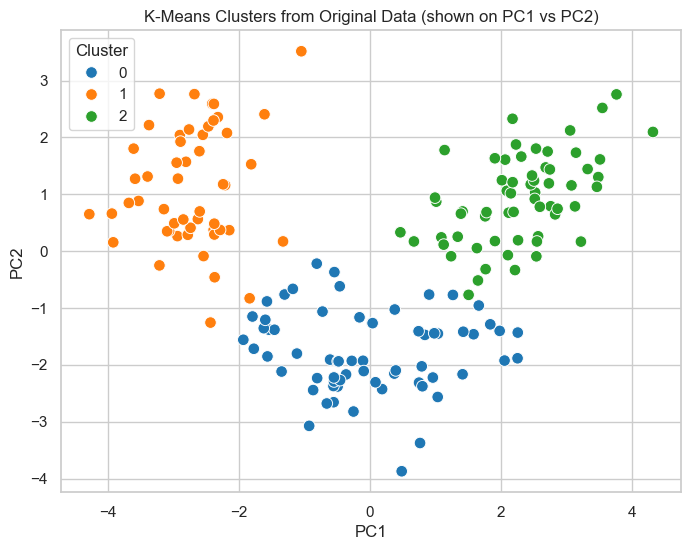

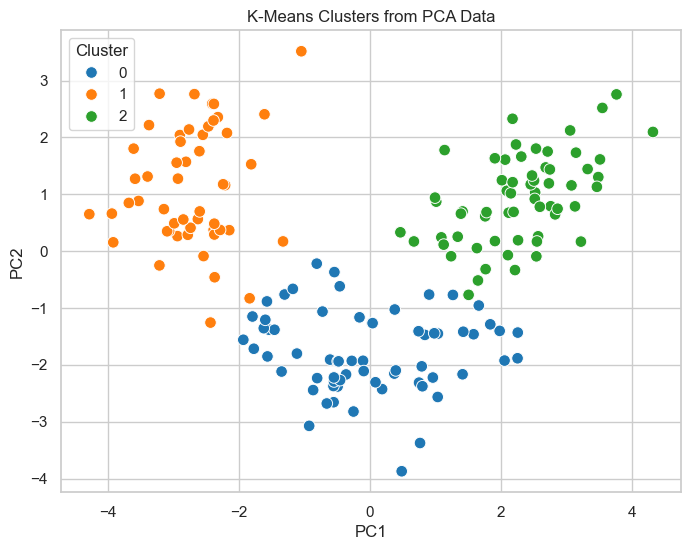

In [9]:
# Visualize original-data clusters using the first two PCA axes
plot_original = pd.DataFrame({
    "PC1": X_pca_full[:, 0],
    "PC2": X_pca_full[:, 1],
    "Cluster": labels_original
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_original, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=70)
plt.title("K-Means Clusters from Original Data (shown on PC1 vs PC2)")
plt.show()

# Visualize PCA clusters
plot_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": labels_pca
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_pca, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=70)
plt.title("K-Means Clusters from PCA Data")
plt.show()

## Task 5 – Comparison & Analysis

- **Silhouette Score:** Higher is better; it indicates better-separated and more cohesive clusters.
- **Davies–Bouldin Index:** Lower is better; it indicates compact, well-separated clusters.
- PCA reduces dimensionality while retaining most of the variance, making clustering potentially faster and easier to visualize.
- Clustering on the original standardized data retains all available feature information.
- PCA can remove redundancy/noise, but it may also discard lower-variance information that can sometimes help clustering.

**Model selection:** Prefer the representation with the stronger silhouette score and lower Davies–Bouldin index, while also considering interpretability and computational efficiency.

## Task 6 – Conclusion

PCA successfully converts the 13 correlated wine measurements into a smaller set of principal components while retaining most of the dataset's information. K-Means was applied to both standardized original data and PCA-transformed data.

**Practical recommendation:** Use PCA before clustering when the dataset has many correlated features, when visualization is important, or when reducing computation is valuable. Use the original standardized features when preserving all feature-level information is more important and dimensionality is already manageable.